In [2]:
import os
import shutil

directory = 'deepfashion-1'
dir_names = []
for filename in os.listdir(directory):
    class_name = filename.split('-')[0] + filename.split('-')[1]
    class_name_dir = os.path.join(directory, class_name)
    if not os.path.exists(class_name_dir):
        os.makedirs(class_name_dir)
    src = os.path.join(directory, filename)
    dst = os.path.join(class_name_dir, filename)
    shutil.move(src, dst)

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import gc
from PIL import Image
import pandas as pd
import os
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
def clean_data(root_dir):
    num_removed = 0
    for class_dir in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_dir)
        if not os.path.isdir(class_path):
            continue
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                os.remove(file_path)
                num_removed += 1
clean_data('deepfashion-1')

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])
test_dataset = datasets.ImageFolder(root='deepfashion-1', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x
model = mnist()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
gc.collect()
epochs = 10
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/10]')
    print("Training loss", (running_loss / total))
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()
    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print("Testing loss", (running_loss_eval / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()


Epoch [1/10]
Training loss 0.5260682079235712
Training accuracy 84.21833333333333 %
Testing loss 7.292706645448136
Testing accuracy 11.44629867351305 %
Epoch [2/10]
Training loss 0.12561727458933988
Training accuracy 96.21833333333333 %
Testing loss 7.6522724586620665
Testing accuracy 11.788617886178862 %
Epoch [3/10]
Training loss 0.07944179943154256
Training accuracy 97.50666666666666 %
Testing loss 8.239986105152925
Testing accuracy 11.531878476679504 %
Epoch [4/10]
Training loss 0.06021951909735799
Training accuracy 98.17333333333333 %
Testing loss 8.348637105768749
Testing accuracy 11.339323919554985 %
Epoch [5/10]
Training loss 0.05013700865457455
Training accuracy 98.43166666666667 %
Testing loss 8.589160749735768
Testing accuracy 11.082584510055627 %
Epoch [6/10]
Training loss 0.04170839079593619
Training accuracy 98.72833333333334 %
Testing loss 8.806394421345258
Testing accuracy 10.055626872058195 %
Epoch [7/10]
Training loss 0.036241017474109925
Training accuracy 98.865 %
Te

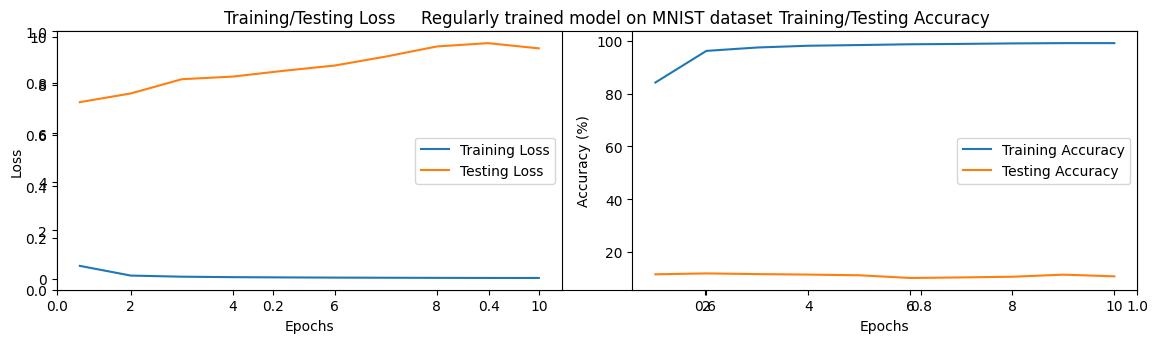

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.title('Regularly trained model on MNIST dataset')
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Testing Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epochs + 1), test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training/Testing Accuracy')
plt.legend()

plt.tight_layout()
plt.show()